# BREACH-AI — Final Prototype Synthesis

## What I set out to investigate

I started from a simple problem: the available flood-scenario catalogue is useful for modelling individual breach locations, but it does not give me a direct empirical description of spatially dependent multi-breach events.

In the preceding notebooks, I therefore tested whether the spatial and system-level structure that is visible in the LIWO data could be turned into a probabilistic scenario-generation mechanism, and then examined what that change would mean for simulated flood losses.

## What I built

This final notebook brings the prototype together rather than introducing another modelling step. I use it to reproduce the main results and check that the saved outputs are consistent with the experiments developed earlier:

1. reconstruction of the live LIWO scenario catalogue;
2. spatial and system-dependence analysis;
3. a provisional handcrafted dependence kernel;
4. tabular ML benchmarking;
5. MLP and GNN dependence modelling;
6. GNN-based probabilistic transition generation;
7. synthetic 2–5 breach event generation;
8. aggregate-loss propagation using the existing single-breach damage estimates;
9. return-period sensitivity;
10. a higher-order event-state architecture for the next stage of the work.

## How I interpret the prototype

The main result is not that one model solves the full flood-risk problem. The experiments show that the **assumption about dependence changes the structure of generated events and the resulting aggregate-loss distribution**, while the available data also expose important limits on what can be estimated directly.

The Random Forest is the strongest predictive benchmark for the consequence-similarity proxy, while the GNN is useful here as a graph-based dependence representation and event-generation mechanism. The pairwise sequential generator also becomes increasingly incomplete as event size grows, which is why I moved toward a higher-order event-state formulation.

The financial calculations in this repository remain **prototype loss proxies**, because they propagate existing single-breach modelled damages rather than recalculating hydraulic interactions between simultaneous breaches. I therefore treat this notebook as a reproducible synthesis of the research prototype, not as a validated joint-failure or portfolio-risk model.

## Reproducibility

The final cells reload the persisted LIWO data and prototype result tables, recreate the main figures, write the synthesis tables, and perform a reproducibility audit.

My aim here is that another researcher can follow the same chain:

**data reconstruction → dependence analysis → model comparison → event generation → financial-loss proxy → limitations → next research step.**


In [ ]:



# Core imports


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path



# Reproducibility


RANDOM_SEED = 2026
np.random.seed(RANDOM_SEED)



# Project paths


ROOT = Path("..").resolve()

DATA_DIR = ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

RESULTS_DIR = ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"
MODEL_DIR = RESULTS_DIR / "models"
LOG_DIR = RESULTS_DIR / "logs"

for directory in [
    DATA_DIR,
    PROCESSED_DIR,
    RESULTS_DIR,
    FIG_DIR,
    TABLE_DIR,
    MODEL_DIR,
    LOG_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )



# Display configuration


pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    180
)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.4f}"
)



# Environment information

print("BREACH-AI — Notebook 08")
print("=" * 50)

print("Project root:", ROOT)
print("Processed data:", PROCESSED_DIR)
print("Results:", RESULTS_DIR)

print("\nNumPy:", np.__version__)
print("Pandas:", pd.__version__)

print("\nSetup complete.")


In [ ]:

# Load persisted LIWO data


SCENARIO_FILE = PROCESSED_DIR / "liwo_scenarios.csv"
CATALOG_FILE = PROCESSED_DIR / "liwo_scenario_catalog.csv"

df_scenarios = pd.read_csv(
    SCENARIO_FILE
)

df_catalog = pd.read_csv(
    CATALOG_FILE
)

print("Scenario rows:", len(df_scenarios))
print("Catalog rows:", len(df_catalog))

print("\nScenario file:")
print(SCENARIO_FILE)

print("\nCatalog file:")
print(CATALOG_FILE)

Scenario rows: 1856
Catalog rows: 1856


In [7]:

# Standard cleaned analysis dataframe


df = df_catalog.copy()

df["return_period"] = pd.to_numeric(
    df["return_period"],
    errors="coerce"
)

df["damage_MEUR_num"] = pd.to_numeric(
    df["damage_MEUR"],
    errors="coerce"
)

df["log_damage"] = np.log1p(
    df["damage_MEUR_num"]
)

df["breach_id"] = pd.to_numeric(
    df["breach_id"],
    errors="coerce"
)

print("Rows:", len(df))
print(
    "Unique breach locations:",
    df["breach_id"].nunique()
)
print(
    "Usable damage:",
    df["damage_MEUR_num"].notna().sum()
)
print(
    "Usable return periods:",
    df["return_period"].notna().sum()
)

Rows: 1856
Unique breach locations: 619
Usable damage: 1830
Usable return periods: 1856


In [8]:

# Source-of-truth prototype results
#
# These values are the final results recorded from the
# completed experiments in Notebooks 01–07.


master_results = pd.DataFrame({
    "Model": [
        "Baseline distance + system + return period",
        "RF multi-scale density",
        "MLP multi-scale",
        "GNN basic",
        "GNN enriched",
        "GNN multi-scale"
    ],
    "MAE": [
        0.220625,
        0.187687,
        0.214975,
        0.212412,
        0.215577,
        0.214990
    ],
    "R2": [
        -0.033695,
        0.189285,
        0.050074,
        0.049490,
        0.060390,
        0.061445
    ]
})

display(master_results)

,Model,MAE,R2
0,Baseline distance + system + return period,0.2206,-0.0337
1,RF multi-scale density,0.1877,0.1893
2,MLP multi-scale,0.2150,0.0501
3,GNN basic,0.2124,0.0495
4,GNN enriched,0.2156,0.0604
5,GNN multi-scale,0.2150,0.0614


In [9]:

# Final 3-breach generator comparison


generator_results = pd.DataFrame({
    "Generator": [
        "Independent",
        "Handcrafted kernel",
        "GNN learned"
    ],
    "Mean_pair_distance_km": [
        97.362695,
        17.833497,
        21.940527
    ],
    "Median_pair_distance_km": [
        98.544066,
        12.110976,
        15.140474
    ],
    "Mean_log_damage_difference": [
        2.796022,
        1.947689,
        1.831013
    ],
    "Same_river_fraction": [
        0.053300,
        0.496233,
        0.433167
    ],
    "Same_dijkring_fraction": [
        0.032600,
        0.428833,
        0.446400
    ],
    "Same_system_fraction": [
        0.015033,
        0.303067,
        0.286800
    ]
})

display(generator_results)

,Generator,Mean_pair_distance_km,Median_pair_distance_km,Mean_log_damage_difference,Same_river_fraction,Same_dijkring_fraction,Same_system_fraction
0,Independent,97.3627,98.5441,2.7960,0.0533,0.0326,0.0150
1,Handcrafted kernel,17.8335,12.1110,1.9477,0.4962,0.4288,0.3031
2,GNN learned,21.9405,15.1405,1.8310,0.4332,0.4464,0.2868


In [11]:

# Higher-order sequential generation completion


completion_master = pd.DataFrame({
    "Event_size": [2, 3, 4, 5],
    "GNN_completion_rate": [
        1.0000,
        0.8832,
        0.7038,
        0.5130
    ],
    "Kernel_completion_rate": [
        1.0000,
        0.9112,
        0.7878,
        0.6562
    ]
})

display(completion_master)

,Event_size,GNN_completion_rate,Kernel_completion_rate
0,2,1.0000,1.0000
1,3,0.8832,0.9112
2,4,0.7038,0.7878
3,5,0.5130,0.6562


In [ ]:

# T4000 3-breach financial-loss proxy


financial_master = pd.DataFrame({
    "Generator": [
        "Independent",
        "Handcrafted kernel",
        "GNN learned"
    ],
    "Mean_MEUR": [
        2126.0586,
        1708.5394,
        1798.5264
    ],
    "Median_MEUR": [
        940.5,
        582.0,
        601.0
    ],
    "P90_MEUR": [
        5331.0,
        4500.0,
        4809.0
    ],
    "P95_MEUR": [
        8023.10,
        7294.0,
        7915.05
    ],
    "P99_MEUR": [
        23062.0,
        15790.0,
        15790.0
    ],
    "Max_MEUR": [
        33400.0,
        27901.0,
        26140.0
    ]
})

display(financial_master)

,Generator,Mean_MEUR,Median_MEUR,P90_MEUR,P95_MEUR,P99_MEUR,Max_MEUR
0,Independent,"2,126.0586",940.5000,"5,331.0000","8,023.1000","23,062.0000","33,400.0000"
1,Handcrafted kernel,"1,708.5394",582.0000,"4,500.0000","7,294.0000","15,790.0000","27,901.0000"
2,GNN learned,"1,798.5264",601.0000,"4,809.0000","7,915.0500","15,790.0000","26,140.0000"


In [ ]:

# Save final synthesis tables


master_results_path = (
    TABLE_DIR / "master_model_comparison.csv"
)

generator_results_path = (
    TABLE_DIR / "generator_comparison_3breach.csv"
)

completion_results_path = (
    TABLE_DIR / "higher_order_completion.csv"
)

financial_results_path = (
    TABLE_DIR / "t4000_financial_comparison.csv"
)

master_results.to_csv(
    master_results_path,
    index=False
)

generator_results.to_csv(
    generator_results_path,
    index=False
)

completion_master.to_csv(
    completion_results_path,
    index=False
)

financial_master.to_csv(
    financial_results_path,
    index=False
)

print("Saved:")
print(" -", master_results_path)
print(" -", generator_results_path)
print(" -", completion_results_path)
print(" -", financial_results_path)

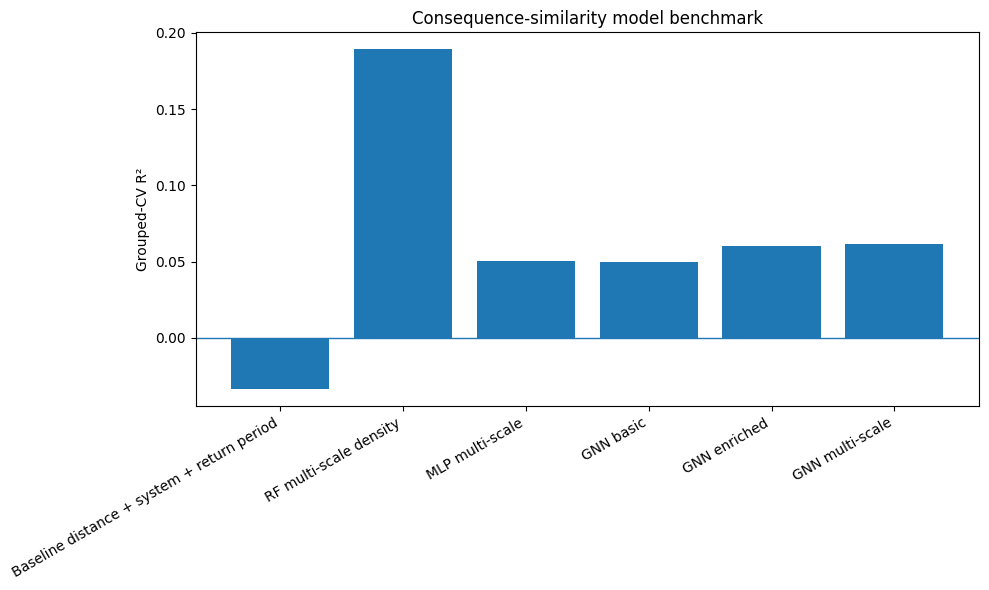

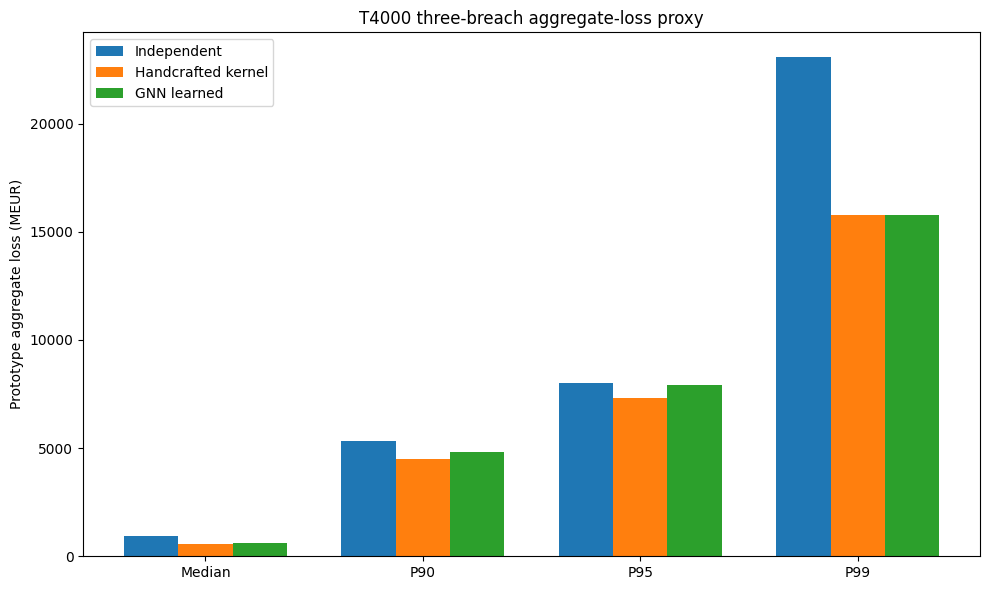

Saved:


In [ ]:

# Final figures



# Figure 1: model benchmark


plt.figure(figsize=(10, 6))

plt.bar(
    master_results["Model"],
    master_results["R2"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.ylabel("Grouped-CV R²")
plt.title(
    "Consequence-similarity model benchmark"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

benchmark_fig = (
    FIG_DIR / "model_benchmark_r2.png"
)

plt.savefig(
    benchmark_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# Figure 2: T4000 financial tails


metrics = [
    "Median_MEUR",
    "P90_MEUR",
    "P95_MEUR",
    "P99_MEUR"
]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 6))

for idx, generator in enumerate(
    financial_master["Generator"]
):

    values = (
        financial_master
        .loc[
            financial_master["Generator"] == generator,
            metrics
        ]
        .iloc[0]
        .to_numpy()
    )

    plt.bar(
        x + (idx - 1) * width,
        values,
        width,
        label=generator
    )

plt.xticks(
    x,
    ["Median", "P90", "P95", "P99"]
)

plt.ylabel(
    "Prototype aggregate loss (MEUR)"
)

plt.title(
    "T4000 three-breach aggregate-loss proxy"
)

plt.legend()

plt.tight_layout()

financial_fig = (
    FIG_DIR / "t4000_financial_tails.png"
)

plt.savefig(
    financial_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(" -", benchmark_fig)
print(" -", financial_fig)

In [18]:
# ============================================================
# Executive summary text
# ============================================================

summary_text = f"""
BREACH-AI — Prototype Executive Summary

OBJECTIVE
Develop a probabilistic AI framework for extending predominantly
single-breach flood scenarios toward spatially dependent multi-breach events.

DATA
- 633 primary breach locations in the live LIWO inventory
- 1,856 scenario records
- 619 scenario-bearing locations
- 610 locations with usable numeric damage observations

MODEL BENCHMARK
Best tabular benchmark:
Random Forest with multi-scale spatial-density features
MAE = 0.1877
R² = 0.1893

Best tested GNN:
Multi-scale GNN
MAE = 0.2150
R² = 0.0614

GENERATOR BEHAVIOUR
For 3-breach events:

Independent mean pair distance:
97.36 km

Handcrafted kernel:
17.83 km

GNN learned:
21.94 km

GNN same-system pair fraction:
28.68%

Independent same-system pair fraction:
1.50%

HIGHER-ORDER GENERATION
Sequential pairwise GNN completion:

2 breaches: 100.0%
3 breaches: 88.3%
4 breaches: 70.4%
5 breaches: 51.3%

This motivates higher-order event-state modelling.

T4000 FINANCIAL PROXY
Independent P95:
8,023.1 MEUR

Handcrafted kernel P95:
7,294.0 MEUR

GNN learned P95:
7,915.1 MEUR

IMPORTANT LIMITATIONS
The current LIWO catalogue does not provide sufficient simultaneous-breach
observations for direct empirical estimation of joint breach probabilities.

The multi-breach financial calculations are aggregate-loss proxies obtained
from existing single-breach modeled damages.

RESEARCH EXTENSION
Future work should combine hydraulic/system connectivity, probabilistic
dependence learning, higher-order event generation, hydraulic consequence
models, uncertainty quantification, climate conditioning, and financial/
insurability analysis.
"""

summary_path = (
    RESULTS_DIR / "BREACH_AI_executive_summary.txt"
)

summary_path.write_text(
    summary_text.strip(),
    encoding="utf-8"
)



1641

In [19]:

# Reproducibility audit


required_files = [
    PROCESSED_DIR / "liwo_scenarios.csv",
    PROCESSED_DIR / "liwo_scenario_catalog.csv",

    TABLE_DIR / "master_model_comparison.csv",
    TABLE_DIR / "generator_comparison_3breach.csv",
    TABLE_DIR / "higher_order_completion.csv",
    TABLE_DIR / "t4000_financial_comparison.csv",

    FIG_DIR / "model_benchmark_r2.png",
    FIG_DIR / "t4000_financial_tails.png",

    RESULTS_DIR / "BREACH_AI_executive_summary.txt"
]

audit = pd.DataFrame({
    "file": [
        str(p.relative_to(ROOT))
        for p in required_files
    ],
    "exists": [
        p.exists()
        for p in required_files
    ]
})

display(audit)

print(
    "\nAll required artifacts present:",
    audit["exists"].all()
)

,file,exists
0,data\processed\liwo_scenarios.csv,True
1,data\processed\liwo_scenario_catalog.csv,True
2,results\tables\master_model_comparison.csv,True
3,results\tables\generator_comparison_3breach.csv,True
4,results\tables\higher_order_completion.csv,True
5,results\tables\t4000_financial_comparison.csv,True
6,results\figures\model_benchmark_r2.png,True
7,results\figures\t4000_financial_tails.png,True
8,results\BREACH_AI_executive_summary.txt,True



All required artifacts present: True
